<div style="background:linear-gradient(135deg,#134e4a 0%,#115e59 55%,#5eead4 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 204 &middot; Capstone 41 &middot; Fairness</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">A Fairness Audit</div>
  <div style="font-size:15px;color:#99f6e4;max-width:820px;line-height:1.6">A care-management model with an AUC of 0.92 enrolls one group at a third of the other's rate. Every fairness check against the label it was trained on comes back clean, because the label is where the problem is.</div>
</div>

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
TL, DK, LT, MUT, GD, RD = "#115e59", "#134e4a", "#5eead4", "#94a3b8", "#047857", "#dc2626"

BASE_URL = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-fairness-audit.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE_URL + fn, sheet_name=sheet)
raw   = load("Data")
notes = load("Notes")
CAP = 0.03                                # the program has room for 3 percent of the panel
print("rows in the patient extract:", len(raw))
raw.head()

rows in the patient extract: 12023


,patient_id,group,age,pcp_visits,er_visits,active_meds,chronic_conditions,prior_cost_k,cost_next_k,conditions_next
0,P20000,B,55,2,0,7,5,4.90,33.11,4
1,P20001,A,60,7,0,1,1,7.04,5.94,3
2,P20002,A,40,1,0,1,0,1.82,1.06,0
3,P20003,A,76,4,0,0,0,1.68,2.18,3
4,P20004,A,50,0,0,1,1,4.43,3.38,0


## Step 1 &middot; The brief

In [2]:
for line in notes.Notes.fillna(""):
    print(line)

CARE MANAGEMENT ENROLLMENT. Twelve thousand patients, one year of history and one year of follow-up.

THE PROGRAM. Extra nursing support, medication review and care coordination for the patients who need
it most. There is capacity for about 3 percent of the panel, so the model ranks everyone and the top
slice is auto-enrolled.

WHAT THE MODEL PREDICTS. Next year's medical cost. The health system does not have a direct measure of
'need', and cost is the number every claims system already produces, so cost became the stand-in.

THE QUESTION. The program has been running for a year. Does it reach the patients who need it, and does
it reach them equally?

A NOTE ON THE GROUP FIELD. Group A and Group B are placeholders for a patient characteristic the health
system is required to monitor for. What matters for the analysis is that the two groups do not have the
same access to care, which is a fact about the health system rather than about the patients.

WHAT IS IN THE EXPORT, as it arrived:


**One sentence in there is the whole chapter:** the health system does not have a measure of need, so cost became the stand-in.

That substitution is not lazy and it is not unusual. Cost is the only number a claims system produces for every patient, every month, without anyone having to define anything. It correlates strongly with illness. It is auditable. Every incentive points at using it.

The question this audit has to answer is not whether the model predicts cost well. It does. The question is whether **cost means the same thing for both groups**, because if it does not, then a model that ranks people perfectly by cost ranks them imperfectly by the thing the program is actually for.

## Step 2 &middot; Cleaning

In [3]:
d = raw.drop_duplicates("patient_id").reset_index(drop=True)
print(f"duplicate patients    {len(raw)-len(d)} dropped -> {len(d)}")

neg = d.prior_cost_k < 0
print(f"negative prior cost   {neg.sum()} rows, from {d.prior_cost_k[neg].min():.2f}k to {d.prior_cost_k[neg].max():.2f}k")
d.loc[neg, "prior_cost_k"] = 0.0

bad_age = (d.age < 18) | (d.age > 110)
print(f"impossible ages       {sorted(d.age[bad_age].tolist())} -> median {d.age[~bad_age].median():.0f}")
d.loc[bad_age, "age"] = d.age[~bad_age].median()

print(f"group not recorded    {d.group.isna().sum()} patients")
print(f"                      kept in the model, excluded from the group comparison")

duplicate patients    23 dropped -> 12000
negative prior cost   14 rows, from -12.63k to -1.25k
impossible ages       [0, 214] -> median 58
group not recorded    96 patients
                      kept in the model, excluded from the group comparison


**A negative cost is a billing adjustment, not care that cost less than nothing.** Setting them to zero is the conservative reading: we know those patients were not high spenders, and we do not know what they actually consumed.

**The 96 patients with no group recorded stay in the model and leave the fairness comparison.** They are patients and the model will score them either way. What we cannot do is assign them to a group in order to make a table balance, and saying so is more honest than a footnote.

## Step 3 &middot; First look

In [4]:
print(f"panel                 {len(d):,} patients, group B {d.group.eq('B').mean():.1%}")
print(f"chronic conditions    A {d.chronic_conditions[d.group=='A'].mean():.2f}   B {d.chronic_conditions[d.group=='B'].mean():.2f}")
print(f"cost next year        A {d.cost_next_k[d.group=='A'].mean():.1f}k   B {d.cost_next_k[d.group=='B'].mean():.1f}k")
print()
print("median cost next year, AT THE SAME NUMBER OF CONDITIONS:")
for c in [2, 3, 4, 5]:
    s = d[d.chronic_conditions == c]
    a, b = s.cost_next_k[s.group=="A"].median(), s.cost_next_k[s.group=="B"].median()
    print(f"  {c} conditions:  A {a:5.1f}k   B {b:5.1f}k   B is {b/a:.0%} of A")

panel                 12,000 patients, group B 29.2%
chronic conditions    A 1.88   B 2.10
cost next year        A 7.0k   B 5.1k

median cost next year, AT THE SAME NUMBER OF CONDITIONS:
  2 conditions:  A   5.6k   B   4.0k   B is 72% of A
  3 conditions:  A   6.7k   B   4.7k   B is 70% of A
  4 conditions:  A   8.3k   B   5.3k   B is 64% of A
  5 conditions:  A   9.5k   B   5.6k   B is 59% of A


**What this shows.** Group B carries more chronic conditions on average and costs less. At any fixed number of conditions, B costs 59 to 72 percent of what A costs. That gap is the entire mechanism: it is not a fact about how ill people are, it is a fact about what reaching care costs them.

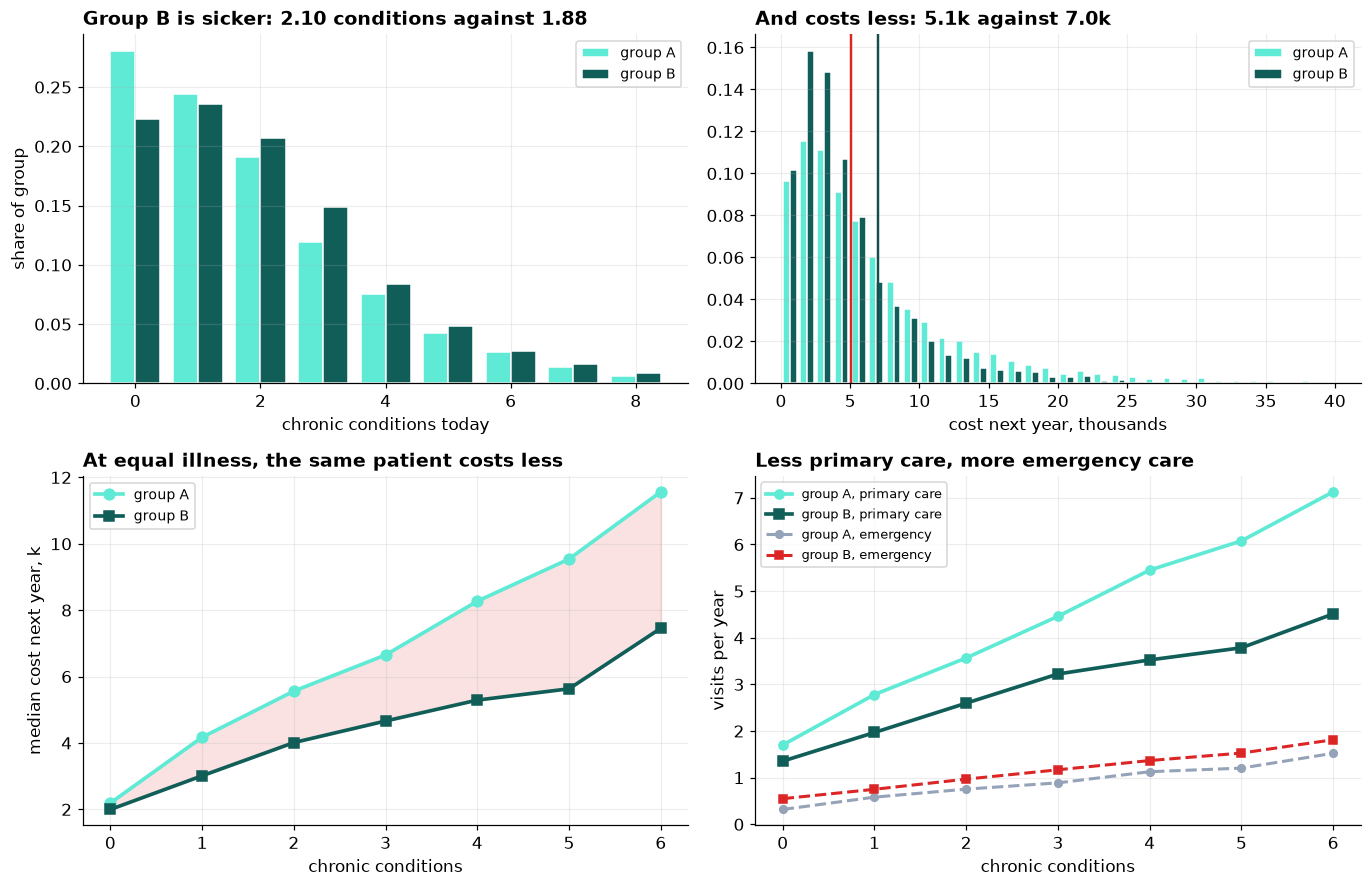

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12.6, 8.2))
A, B = d[d.group=="A"], d[d.group=="B"]

ax[0,0].hist([A.chronic_conditions, B.chronic_conditions], bins=np.arange(0, 10)-0.5, density=True,
             color=[LT, TL], edgecolor="white", label=["group A","group B"])
ax[0,0].set_xlabel("chronic conditions today"); ax[0,0].set_ylabel("share of group")
ax[0,0].legend(fontsize=9)
ax[0,0].set_title(f"Group B is sicker: {B.chronic_conditions.mean():.2f} conditions against {A.chronic_conditions.mean():.2f}")

ax[0,1].hist([A.cost_next_k, B.cost_next_k], bins=np.linspace(0, 40, 33), range=(0, 40), density=True,
             color=[LT, TL], edgecolor="white", label=["group A","group B"])
ax[0,1].axvline(A.cost_next_k.mean(), color=DK, lw=1.6); ax[0,1].axvline(B.cost_next_k.mean(), color=RD, lw=1.6)
ax[0,1].set_xlabel("cost next year, thousands"); ax[0,1].legend(fontsize=9)
ax[0,1].set_title(f"And costs less: {B.cost_next_k.mean():.1f}k against {A.cost_next_k.mean():.1f}k")

cc = np.arange(0, 7)
am = [d.cost_next_k[(d.group=="A") & (d.chronic_conditions==c)].median() for c in cc]
bm = [d.cost_next_k[(d.group=="B") & (d.chronic_conditions==c)].median() for c in cc]
ax[1,0].plot(cc, am, "o-", color=LT, lw=2.4, ms=7, label="group A")
ax[1,0].plot(cc, bm, "s-", color=TL, lw=2.4, ms=7, label="group B")
ax[1,0].fill_between(cc, bm, am, color=RD, alpha=0.13)
ax[1,0].set_xlabel("chronic conditions"); ax[1,0].set_ylabel("median cost next year, k")
ax[1,0].legend(fontsize=9)
ax[1,0].set_title("At equal illness, the same patient costs less")

ae = [A.er_visits[A.chronic_conditions==c].mean() for c in cc]
be = [B.er_visits[B.chronic_conditions==c].mean() for c in cc]
ap = [A.pcp_visits[A.chronic_conditions==c].mean() for c in cc]
bp = [B.pcp_visits[B.chronic_conditions==c].mean() for c in cc]
ax[1,1].plot(cc, ap, "o-", color=LT, lw=2.4, ms=6, label="group A, primary care")
ax[1,1].plot(cc, bp, "s-", color=TL, lw=2.4, ms=6, label="group B, primary care")
ax[1,1].plot(cc, ae, "o--", color=MUT, lw=2.0, ms=5, label="group A, emergency")
ax[1,1].plot(cc, be, "s--", color=RD, lw=2.0, ms=5, label="group B, emergency")
ax[1,1].set_xlabel("chronic conditions"); ax[1,1].set_ylabel("visits per year")
ax[1,1].legend(fontsize=8.2)
ax[1,1].set_title("Less primary care, more emergency care")
plt.tight_layout(); plt.show()

**Top left.** Group B carries more chronic conditions.

**Top right.** And costs the system less money. Those two facts together are not a paradox, they are the finding.

**Bottom left.** The same comparison held at a fixed level of illness. The shaded gap is what a dollar-based measure will read as "less sick" and what is actually "less served."

**Bottom right.** Where the missing care goes. At every level of illness group B has fewer primary-care visits and more emergency visits, which is the shape of care that is harder to reach until it cannot be postponed. **The data contains the evidence of its own bias, in columns the model uses as predictors rather than as warnings.**

## Step 4 &middot; The model, exactly as deployed

In [6]:
CLAIMS = ["age","pcp_visits","er_visits","active_meds","prior_cost_k"]
tr, te = train_test_split(d, test_size=0.4, random_state=7, stratify=d.group.fillna("Z"))
te = te.copy()
def fit_score(target, feats):
    m = GradientBoostingRegressor(random_state=0, n_estimators=200, max_depth=3)
    m.fit(tr[feats], tr[target]); return m.predict(te[feats])

te["risk_cost"] = fit_score("cost_next_k", CLAIMS)
k = int(len(te)*CAP)
te["enrol_cost"] = te.risk_cost.rank(ascending=False) <= k
G = te[te.group.notna()].copy()

hi = te.cost_next_k > te.cost_next_k.quantile(1-CAP)
print(f"evaluation panel      {len(te):,} patients, {len(G):,} with a group recorded")
print(f"program capacity      {k} places ({CAP:.0%})")
print(f"AUC, top {CAP:.0%} of cost  {roc_auc_score(hi, te.risk_cost):.3f}")
print(f"corr(predicted, actual cost)  {np.corrcoef(te.risk_cost, te.cost_next_k)[0,1]:.3f}")

evaluation panel      4,800 patients, 4,761 with a group recorded
program capacity      144 places (3%)
AUC, top 3% of cost  0.920
corr(predicted, actual cost)  0.610


**An AUC of 0.920.** By any normal standard this model works. It was built on the five features a claims system has, it identifies the most expensive three percent of the panel with high accuracy, and if the review had stopped at this cell it would have passed.

## Step 5 &middot; Who actually gets in

In [7]:
ra, rb = G.enrol_cost[G.group=="A"].mean(), G.enrol_cost[G.group=="B"].mean()
print(f"enrollment rate   group A {ra:.2%}   group B {rb:.2%}")
print(f"impact ratio      {rb/ra:.2f}   {'FAILS' if rb/ra < 0.8 else 'passes'} the four-fifths rule")
print(f"B share of places {G.group[G.enrol_cost].eq('B').mean():.1%}, against {G.group.eq('B').mean():.1%} of the panel")

enrollment rate   group A 3.72%   group B 1.36%
impact ratio      0.36   FAILS the four-fifths rule
B share of places 13.2%, against 29.4% of the panel


**A ratio of 0.36 against a threshold of 0.80.** Group B is 29.4 percent of the panel and receives 13.2 percent of the places. This is the finding that starts an audit, and on its own it settles nothing, because there is an obvious defense: if group B really does cost less, a cost model is right to rank them lower and the disparity is the data, not the model.

The rest of the chapter is about whether that defense holds.

## Step 6 &middot; The audit that comes back clean

In [8]:
G["dec"] = pd.qcut(G.risk_cost, 10, labels=False)
cal = G.groupby(["dec","group"]).agg(predicted=("risk_cost","mean"), actual=("cost_next_k","mean")).reset_index()
print(cal.pivot(index="dec", columns="group", values=["predicted","actual"]).round(1).tail(4).to_string())
print()
top = G[G.dec >= 8]
for g in ["A","B"]:
    s = top[top.group == g]
    print(f"  top two deciles, group {g}: predicted {s.risk_cost.mean():5.1f}k, "
          f"actual {s.cost_next_k.mean():5.1f}k, ratio {s.cost_next_k.mean()/s.risk_cost.mean():.2f}")

      predicted       actual      
group         A     B      A     B
dec                               
6           6.8   6.8    7.5   5.4
7           8.2   8.2    8.7   7.6
8          10.5  10.2   11.1   9.0
9          17.3  15.9   17.2  13.6

  top two deciles, group A: predicted  14.1k, actual  14.3k, ratio 1.01
  top two deciles, group B: predicted  12.3k, actual  10.7k, ratio 0.87


**The model is close to calibrated on cost, and where it is not, it errs in group B's favor.** In the top two deciles it predicts 14.1k for group A and they cost 14.3k. It predicts 12.3k for group B and they cost 10.7k, so if anything it over-estimates what group B will spend.

Read that as an auditor would. Every standard check against the label says the model is doing its job, and the one imperfection points *away* from harm to group B. **A fairness review that audits a model against its own training label cannot find a problem that lives in the label**, and this is what that looks like from the inside.

## Step 7 &middot; Changing what we measure against

In [9]:
for dd in [7, 8, 9]:
    s = G[G.dec == dd]
    a, b = s.chronic_conditions[s.group=="A"].mean(), s.chronic_conditions[s.group=="B"].mean()
    print(f"risk decile {dd+1:2d}:  conditions  A {a:.2f}   B {b:.2f}   B carries {b/a-1:+.0%}")
up = G[G.dec >= 7]
a, b = up.chronic_conditions[up.group=="A"].mean(), up.chronic_conditions[up.group=="B"].mean()
print(f"\ndeciles 8 to 10 pooled: A {a:.2f}   B {b:.2f}   B carries {b/a-1:+.0%} more conditions")
print("\nat the same predicted risk, group B patients are sicker.")

risk decile  8:  conditions  A 2.31   B 3.19   B carries +38%
risk decile  9:  conditions  A 2.92   B 3.76   B carries +29%
risk decile 10:  conditions  A 4.13   B 4.65   B carries +12%

deciles 8 to 10 pooled: A 3.19   B 3.69   B carries +16% more conditions

at the same predicted risk, group B patients are sicker.


**At equal predicted risk, group B carries 16 percent more chronic conditions**, and in the eighth decile the gap is 38 percent.

That is the defense answered. The model is not ranking group B lower because they are healthier. It is ranking them lower because the same illness generates fewer dollars for them, and the model was told to find dollars. **Every patient the model treats as equivalent to a group A patient is in fact sicker than them**, and the program is allocating on the wrong ordering.

Nothing about this is visible in accuracy, calibration or any error rate computed against cost.

## Step 8 &middot; Four things we could do about it

In [10]:
te["risk_need"] = fit_score("conditions_next", CLAIMS + ["chronic_conditions"])
G["risk_need"] = te.loc[G.index, "risk_need"]
G["enrol_need"] = G.risk_need.rank(ascending=False) <= int(len(G)*CAP)

rate = k/len(te)
tc = {g: G.risk_cost[G.group==g].quantile(1-rate) for g in ["A","B"]}
tn = {g: G.risk_need[G.group==g].quantile(1-rate) for g in ["A","B"]}
G["enrol_parity"] = [r.risk_cost >= tc[r.group] for _, r in G.iterrows()]
G["enrol_both"]   = [r.risk_need >= tn[r.group] for _, r in G.iterrows()]

HIN = (G.conditions_next >= G.conditions_next.quantile(0.80)).astype(int)
G["y_need"] = HIN
rows = []
for lab, col in [("as deployed, cost label","enrol_cost"),
                 ("cost label, group thresholds","enrol_parity"),
                 ("need label, one threshold","enrol_need"),
                 ("need label, group thresholds","enrol_both")]:
    s = G[G[col]]
    ra, rb = G[col][G.group=="A"].mean(), G[col][G.group=="B"].mean()
    rows.append([lab, round(rb/ra, 2), f"{G.group[G[col]].eq('B').mean():.1%}",
                 round(s.conditions_next.mean(), 2), f"{s.y_need.mean():.1%}"])
print(pd.DataFrame(rows, columns=["approach","B/A ratio","B share of places",
                                  "enrollees' conditions next year","truly high-need"]).to_string(index=False))

                    approach  B/A ratio B share of places  enrollees' conditions next year truly high-need
     as deployed, cost label       0.36             13.2%                             5.42           84.7%
cost label, group thresholds       1.02             29.9%                             5.47           85.4%
   need label, one threshold       0.59             19.7%                             5.49           86.6%
need label, group thresholds       1.02             29.9%                             5.46           84.7%


**The two fixes do different jobs and neither does both.**

**Changing the label helps most on who gets in.** Training on next year's condition count rather than next year's cost raises the share of enrollees who are genuinely high-need from 84.7 to **86.6 percent**, the best of the four, and lifts group B's ratio from 0.36 to 0.59. It does not reach parity, because the features the model uses, visits and prior cost, carry the same access gap the label did. **You cannot fully repair a label problem through a feature set that has the same problem.**

**Group-specific thresholds deliver parity by construction** and improve targeting only slightly, because they reorder nobody. They take the same ranking and cut it in two places.

**Doing both gives parity and gives back the targeting gain**, at 84.7 percent. That is the honest result and it is not the tidy one: on this panel the combination is no better at finding high-need patients than the cost model was, it is just far more evenly distributed.

The recommendation that follows is the label change, because it is the only one that improves the measurement rather than redistributing an unimproved one, with thresholds as a policy decision layered on top and reported as such.

## Step 9 &middot; Why you cannot have everything

In [11]:
def audit(y, sc, name):
    print(f"--- target: {name} ---")
    for g in ["A","B"]: print(f"    base rate, group {g}: {y[G.group==g].mean():.1%}")
    def rates(mask):
        out = {}
        for g in ["A","B"]:
            m = (G.group == g); p = mask[m]; yy = y[m]
            tp = ((p==1)&(yy==1)).sum(); fp = ((p==1)&(yy==0)).sum()
            fn = ((p==0)&(yy==1)).sum(); tn2 = ((p==0)&(yy==0)).sum()
            out[g] = dict(ppv=tp/max(tp+fp,1), fpr=fp/max(fp+tn2,1), fnr=fn/max(fn+tp,1))
        return out
    t1 = sc.quantile(0.80); r1 = rates((sc >= t1).astype(int))
    scB, yB = sc[G.group=="B"], y[G.group=="B"]
    cand = np.quantile(scB, np.linspace(0.3, 0.999, 600))
    bf = min(cand, key=lambda c: abs(((scB>=c)&(yB==0)).sum()/max((yB==0).sum(),1) - r1["A"]["fpr"]))
    bp = min(cand, key=lambda c: abs(((scB>=c)&(yB==1)).sum()/max((scB>=c).sum(),1) - r1["A"]["ppv"]))
    out = []
    for lab, tB in [("one threshold for all", t1), ("equalize false-positive rate", bf),
                    ("equalize precision", bp)]:
        r = rates(((( G.group=="A")&(sc>=t1)) | ((G.group=="B")&(sc>=tB))).astype(int))
        out.append([lab, round(abs(r["A"]["ppv"]-r["B"]["ppv"]), 3),
                    round(abs(r["A"]["fpr"]-r["B"]["fpr"]), 3),
                    f'{r["A"]["fnr"]:.3f} / {r["B"]["fnr"]:.3f}',
                    round(abs(r["A"]["fnr"]-r["B"]["fnr"]), 3)])
    print(pd.DataFrame(out, columns=["rule","precision gap","false-positive gap",
                                     "miss rate A / B","miss-rate gap"]).to_string(index=False)); print()

audit((G.cost_next_k >= G.cost_next_k.quantile(0.80)).astype(int), G.risk_cost, "high COST, the deployed label")
audit(HIN, G.risk_need, "high NEED, the corrected label")

--- target: high COST, the deployed label ---
    base rate, group A: 22.9%
    base rate, group B: 13.1%
                        rule  precision gap  false-positive gap miss rate A / B  miss-rate gap
       one threshold for all          0.094               0.049   0.407 / 0.522          0.115
equalize false-positive rate          0.176               0.001   0.407 / 0.424          0.017
          equalize precision          0.002               0.098   0.407 / 0.761          0.354

--- target: high NEED, the corrected label ---
    base rate, group A: 31.4%
    base rate, group B: 35.9%
                        rule  precision gap  false-positive gap miss rate A / B  miss-rate gap
       one threshold for all          0.051               0.024   0.541 / 0.639          0.098
equalize false-positive rate          0.032               0.001   0.541 / 0.567          0.026
          equalize precision          0.001               0.028   0.541 / 0.514          0.027



**On the cost label, every gap you close opens another one.** Equalize the false-positive rate and the precision gap widens to 0.176. Equalize precision instead and the false-negative gap explodes to **0.354**: group B's miss rate goes to 76 percent against group A's 41. There is no threshold pair that closes all three, and this is not a defect of the search. It is arithmetic. When two groups have different base rates, calibration and equal error rates are mutually incompatible, and no amount of tuning gets around it.

**Now read the second table.** On the corrected label, once you equalize either criterion every remaining gap is under 0.033. The trade-off did not disappear, but it shrank by an order of magnitude.

The reason is in the base rates. On the cost label they are 22.9 percent and 13.1 percent, a gap of nearly ten points that exists **because the label is dollars and one group spends fewer of them**. On the need label they are 31.4 and 35.9, and what remains is a real difference in illness rather than an artifact of access.

**The severity of the impossibility was itself a symptom.** A large part of what looked like an unavoidable ethical trade-off was manufactured by the choice of what to predict, and it went away when that choice was corrected.

## Step 10 &middot; What we would tell the health system

In [12]:
s = G[G.enrol_need]
print("THE FINDING")
print(f"  the deployed model enrolls group B at {G.enrol_cost[G.group=='B'].mean()/G.enrol_cost[G.group=='A'].mean():.2f}x group A's rate")
print(f"  it is not because they are healthier: at equal predicted risk they carry {b/a-1:+.0%} more conditions")
print(f"  every fairness check against the cost label passes")
print()
print("THE CAUSE")
rat = np.mean([d.cost_next_k[(d.group=="B") & (d.chronic_conditions==c)].median() /
               d.cost_next_k[(d.group=="A") & (d.chronic_conditions==c)].median() for c in [2,3,4,5]])
print(f"  cost is a proxy for need, and at equal illness it reads {1-rat:.0%} lower for group B")
print()
print("THE FIX")
print(f"  retrain on next year's condition count: high-need share of enrollees "
      f"{G[G.enrol_cost].y_need.mean():.1%} -> {s.y_need.mean():.1%}")
print(f"  group B share of places {G.group[G.enrol_cost].eq('B').mean():.1%} -> {G.group[G.enrol_need].eq('B').mean():.1%}"
      f" (panel share {G.group.eq('B').mean():.1%})")
print(f"  parity thresholds on top are a policy choice, and should be reported as one")

THE FINDING
  the deployed model enrolls group B at 0.36x group A's rate
  it is not because they are healthier: at equal predicted risk they carry +16% more conditions
  every fairness check against the cost label passes

THE CAUSE
  cost is a proxy for need, and at equal illness it reads 34% lower for group B

THE FIX
  retrain on next year's condition count: high-need share of enrollees 84.7% -> 86.6%
  group B share of places 13.2% -> 19.7% (panel share 29.4%)
  parity thresholds on top are a policy choice, and should be reported as one


**The model was never broken. It was answering a question nobody meant to ask.** It was asked to find the patients who will generate the most billing, it did that with an AUC of 0.92, and the program assumed those were the patients who most needed a nurse.

**The cheapest useful change is not an algorithm.** It is measuring the thing the program exists to affect. Condition counts were already in the record and were not being used as the target.

**And the audit has to be built in.** A fairness review scheduled after deployment, run against the training label, would have returned clean on this model every time.

## Step 11 &middot; What this does not settle

**Condition count is also a proxy.** It comes from diagnoses on a problem list, and a diagnosis requires someone to have been seen. It is less sensitive to access than dollars are, which is why it is an improvement, but the direction of its residual bias is the same one, so the true disparity is probably larger than measured here.

**Two groups, one attribute.** Real audits have to handle several attributes at once and their intersections, where the sample in each cell gets small quickly and the multiple-comparison problem is severe.

**Nothing here measures the program's effect.** Everything is about who gets a place. Whether care management actually helps, and whether it helps both groups equally, is a causal question this observational panel cannot answer and a randomized rollout could.

**Parity was imposed on a fixed capacity.** Every place given to one group is taken from another, which is why parity thresholds cost targeting. If the real answer is that the program is too small, no allocation rule fixes it.

**The four-fifths rule is a legal screening device, not a definition of fairness.** A model can pass it and still be doing what this one does, and a model can fail it for reasons that are entirely justified. It starts audits; it does not finish them.